# _**COMP 3610 - ASSIGNMENT 2**_
### _Samuel Soman - 816039318_

This assignment comprises of building, evaluating and interpreting machine models to predict taxi trip tip amounts using the NYC Yellow Taxi Trip dataset. Machine Learning fundamentals, feature engineering, model evaluation and deep learning with PyTorch used.

**Learning Objectives**
1. Perform feature engineering and data preprocessing for machine learning pipelines
2. Train and tune classification and regression models using Scikit-learn
3. Build and train a neural network using PyTorch
4. Evaluate models using appropriate metrics and cross-validation
5. Interpret model outputs and communicate findings effectively

**Prediction Tasks:**
1. **Regression:** Predict tip_amount (continuous)
2. **Classification:** Predict whether a trip will receive a [high tip] (tip_amount > 20% of fare_amount)

**Dataset:** NYC Yellow Taxi Trip Records - January 2024 (approximately 2.9 Million rows raw data). Only credit card payments (payment_type = 1) are used for modelling because tip amounts are reliably recorded only for card transactions.


---
# **Part 1: Data Preprocessing & Feature Engineering**
---

This section establishes the analytical foundation for the entire modelling workflow. The objective is to transform raw operational taxi data into a reliable, model-ready dataset with consistent semantics and defensible assumptions. Each preprocessing step is designed to reduce noise, remove invalid records, and prevent downstream bias or leakage. Feature engineering then translates domain behavior (time, trip characteristics, and geography) into structured signals that machine learning models can exploit.

## <u>1.0 Setup and Imports</u>

This setup cell standardizes the runtime environment and ensures all dependencies are available before any data operations begin. Reproducibility controls are applied early ( [random_state] and plotting defaults) so that results and visuals remain consistent across runs. Establishing these settings at the top also improves auditability, since every later step depends on this initial configuration. In technical reporting terms, this cell defines the computational context for the experiment.

In [1]:
# Core libraries imports
import os, requests, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global settings and configs.
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Core imports successful!")

Core imports successful!


## <u>1.1 Data Ingestion & Cleaning</u>

The cells below download the NYC Yellow Taxi Trip dataset (January 2024) and the Taxi Zone Lookup table, then apply the same cleaning pipeline developed in Assignment 1.

At this stage, the goal is to enforce data quality constraints before any modelling decisions are made. The cleaning rules are intentionally conservative and grounded in operational plausibility, for example valid trip duration, positive fare values, and correct event ordering. This protects model training from extreme outliers and malformed records that can distort error metrics and feature relationships. Using the same core cleaning logic as Assignment 1 also maintains methodological continuity and makes your pipeline easier to justify academically.

In [2]:
# URLs and paths of data to be used
TRIP_DATA_URL  = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_LOOKUP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

RAW_DIR = os.path.join("data", "raw")
os.makedirs(RAW_DIR, exist_ok=True)

TRIP_DATA_PATH  = os.path.join(RAW_DIR, "yellow_tripdata_2024-01.parquet")
ZONE_LOOKUP_PATH = os.path.join(RAW_DIR, "taxi_zone_lookup.csv")


def download_file(url, dest_path):
    """Download a file if it does not already exist."""
    if os.path.exists(dest_path):
        print(f"Already exists, skipping: {dest_path}")
        return
    print(f"Downloading {url} ...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(dest_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    size_mb = os.path.getsize(dest_path) / (1024 * 1024)
    print(f"Saved to {dest_path} ({size_mb:.1f} MB)")


download_file(TRIP_DATA_URL, TRIP_DATA_PATH)
download_file(ZONE_LOOKUP_URL, ZONE_LOOKUP_PATH)

# Load raw data 
df_raw = pd.read_parquet(TRIP_DATA_PATH)
zone_df = pd.read_csv(ZONE_LOOKUP_PATH)

print(f"\nTrip data shape : {df_raw.shape}")
print(f"Zone lookup shape: {zone_df.shape}")

Saved to data\raw\yellow_tripdata_2024-01.parquet (47.6 MB)
Saved to data\raw\taxi_zone_lookup.csv (0.0 MB)

Trip data shape : (2964624, 19)
Zone lookup shape: (265, 4)


In [3]:
# DATA CLEANING  (reused from Assignment 1 and improved slight for this assignment)

df = df_raw.copy()
initial_rows = len(df)

df["tpep_pickup_datetime"]  = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Remove nulls in critical columns
critical_cols = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
                 "PULocationID", "DOLocationID", "fare_amount"]
before = len(df)
df = df.dropna(subset=critical_cols)
print(f"Nulls in critical cols  → removed {before - len(df):,}")

# Keep January 2024 only
before = len(df)
df = df[(df["tpep_pickup_datetime"] >= "2024-01-01") &
        (df["tpep_pickup_datetime"] <  "2024-02-01")]
print(f"Date filter (Jan 2024)  → removed {before - len(df):,}")

# Dropoff must be after pickup
before = len(df)
df = df[df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"]]
print(f"Dropoff > pickup        → removed {before - len(df):,}")

# Distance > 0, fare in (0, 500], total > 0
before = len(df)
df = df[df["trip_distance"] > 0]
df = df[(df["fare_amount"] > 0) & (df["fare_amount"] <= 500)]
df = df[df["total_amount"] > 0]
print(f"Distance / fare filter  → removed {before - len(df):,}")

# Compute trip duration (needed for further filters)
df["trip_duration_minutes"] = (
    (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

# Duration 1–300 min, distance ≤ 200 mi
before = len(df)
df = df[(df["trip_distance"] <= 200) &
        (df["trip_duration_minutes"] <= 300) &
        (df["trip_duration_minutes"] >= 1)]
print(f"Duration / distance cap → removed {before - len(df):,}")

# Passenger count 1–9
before = len(df)
df = df[(df["passenger_count"] >= 1) & (df["passenger_count"] <= 9)]
print(f"Passenger count filter  → removed {before - len(df):,}")

removed = initial_rows - len(df)
print(f"\n{'='*50}")
print(f"Original rows : {initial_rows:,}")
print(f"Cleaned rows  : {len(df):,}")
print(f"Removed       : {removed:,}  ({removed/initial_rows*100:.1f}%)")

Nulls in critical cols  → removed 0
Date filter (Jan 2024)  → removed 18
Dropoff > pickup        → removed 870
Distance / fare filter  → removed 94,181
Duration / distance cap → removed 10,444
Passenger count filter  → removed 145,509

Original rows : 2,964,624
Cleaned rows  : 2,713,602
Removed       : 251,022  (8.5%)


## <u>1.2 Filter for Credit Card Payments</u>

Since tip_amount is only reliably recorded for credit card transactions (payment_type = 1), we filter the dataset accordingly before any modelling work.

This decision is critical for label integrity. Including payment types where tips are missing or inconsistently recorded would introduce systematic measurement error and weaken both regression and classification targets. Restricting the analysis to card payments improves internal validity, even though it narrows the population represented by the final models. In reporting terms, this is a deliberate trade-off between completeness and target reliability.

In [4]:
before = len(df)
df = df[df["payment_type"] == 1].copy()
print(f"Filtered to credit card only: {len(df):,} rows  "
      f"(removed {before - len(df):,} non-credit-card rows)")

Filtered to credit card only: 2,268,723 rows  (removed 444,879 non-credit-card rows)


## <u>1.3 Feature Engineering</u>

We create four groups of features:

| Group | Features |
|-------|----------|
| **Temporal** | [pickup_hour], [pickup_day_of_week] (0 = Mon), [is_weekend] |
| **Trip** | [trip_duration_minutes] (from cleaning), [trip_speed_mph], [log_trip_distance] |
| **Fare** | [fare_per_mile], [fare_per_minute] |
| **Zone** | One-hot encoded pickup & dropoff **borough** via the taxi zone lookup table |

Feature engineering is where raw transactional records are translated into behavior-oriented predictors. Temporal variables capture demand and rider context, trip variables capture travel intensity, and fare-normalized variables represent pricing structure beyond raw totals. Geographic encoding at borough level introduces interpretable spatial effects without the dimensional burden of full zone identifiers. Together, these features provide a balanced representation of rider, route, and fare dynamics required for robust supervised learning.

In [5]:
# Temporal features 
df["pickup_hour"]        = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek   # 0 = Monday
df["is_weekend"]         = (df["pickup_day_of_week"] >= 5).astype(int)

# Trip features 
# trip_duration_minutes already computed during cleaning
df["trip_speed_mph"] = (
    df["trip_distance"] / (df["trip_duration_minutes"] / 60)
).clip(upper=80)                       # cap unrealistic speeds at 80 mph

df["log_trip_distance"] = np.log1p(df["trip_distance"])

# Fare features
df["fare_per_mile"] = np.where(
df["trip_distance"] > 0,
df["fare_amount"] / df["trip_distance"], 0,
)
df["fare_per_minute"] = np.where(
    df["trip_duration_minutes"] > 0,
    df["fare_amount"] / df["trip_duration_minutes"],
    0,
)

# Zone features (borough from taxi zone lookup) 
# Merge pickup borough
df = df.merge(
    zone_df[["LocationID", "Borough"]].rename(
        columns={"LocationID": "PULocationID", "Borough": "pickup_borough"}
    ),
    on="PULocationID", how="left",
)
# Merge dropoff borough
df = df.merge(
    zone_df[["LocationID", "Borough"]].rename(
        columns={"LocationID": "DOLocationID", "Borough": "dropoff_borough"}
    ),
    on="DOLocationID", how="left",
)

df["pickup_borough"]  = df["pickup_borough"].fillna("Unknown")
df["dropoff_borough"] = df["dropoff_borough"].fillna("Unknown")

# One-hot encode boroughs
df = pd.get_dummies(df, columns=["pickup_borough", "dropoff_borough"],
                    prefix=["pu_boro", "do_boro"])

# Fill residual NaN in surcharge columns 
for col in ["congestion_surcharge", "Airport_fee"]:
    df[col] = df[col].fillna(0)

print("Feature engineering complete.")
print(f"Dataset shape: {df.shape}")
print(f"\nNew feature samples:")
display(df[["pickup_hour", "pickup_day_of_week", "is_weekend",
            "trip_speed_mph", "log_trip_distance",
            "fare_per_mile", "fare_per_minute"]].head(8))

Feature engineering complete.
Dataset shape: (2268723, 41)

New feature samples:


,pickup_hour,pickup_day_of_week,is_weekend,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute
0,0,0,0,16.363636,1.029619,5.555556,1.515152
1,0,0,0,15.739535,1.740466,4.957447,1.300465
2,0,0,0,10.120482,0.875469,7.142857,1.204819
3,0,0,0,7.868852,0.587787,9.875000,1.295082
4,0,0,0,8.708183,1.740466,6.297872,0.914050
5,0,0,0,24.921305,2.469793,4.223660,1.754319
6,0,0,0,7.124011,0.559616,10.533333,1.250660
7,0,0,0,7.955801,0.788457,12.416667,1.646409


## <u>1.4 Target Variable Creation</u>

| Target | Type | Definition |
|--------|------|------------|
| tip_amount | Continuous | Raw tip amount in USD (regression) |
| high_tip | Binary | 1 if tip_amount > 20% of fare_amount, else 0 (classification) |

This step formalizes the two predictive tasks and aligns them to evaluation strategy. The regression target captures absolute monetary behavior, while the classification target captures decision-oriented tipping behavior. Defining [high_tip] using a percentage threshold makes the class label more economically meaningful than a fixed dollar cutoff across fare sizes. This dual-target setup supports broader model comparison and demonstrates competency across both continuous and discrete prediction frameworks.

In [6]:
# Regression target already exists as tip_amount
# Classification target
df["high_tip"] = (df["tip_amount"] > 0.20 * df["fare_amount"]).astype(int)

print("Target variable distribution:")
print(f"  tip_amount  — mean: ${df['tip_amount'].mean():.2f}, "
      f"median: ${df['tip_amount'].median():.2f}, "
      f"std: ${df['tip_amount'].std():.2f}")
print(f"\n  high_tip class counts:")
print(df["high_tip"].value_counts().to_string())
print(f"\n  high_tip class proportions:")
print(df["high_tip"].value_counts(normalize=True).round(4).to_string())

Target variable distribution:
  tip_amount  — mean: $4.15, median: $3.14, std: $3.84

  high_tip class counts:
high_tip
1    1723627
0     545096

  high_tip class proportions:
high_tip
1    0.7597
0    0.2403


## <u>1.5 Data Splitting & Scaling</u>

- **70 / 15 / 15** train / validation / test split
- Stratified on [high_tip] to preserve class balance across splits
- **StandardScaler** fitted on **training data only** and applied to all splits
- One-hot (binary) borough features are **not** scaled

This stage enforces proper experimental design and protects against data leakage. The three-way split supports model development, tuning, and final unbiased evaluation on unseen data. Stratification preserves class proportions for the classification task, making validation and test metrics more stable and representative. Scaling only numeric features, and fitting the scaler on training data only, ensures mathematically fair preprocessing while retaining interpretability for binary indicators.

In [7]:
# Scikit-learn: Splitting & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define feature columns
NUMERIC_FEATURES = [
    "passenger_count", "trip_distance", "RatecodeID",
    "fare_amount", "extra", "mta_tax", "tolls_amount",
    "improvement_surcharge", "congestion_surcharge", "Airport_fee",
    "pickup_hour", "pickup_day_of_week",
    "trip_duration_minutes", "trip_speed_mph",
    "log_trip_distance", "fare_per_mile", "fare_per_minute",
]

BINARY_FEATURES = ["is_weekend"] + [
    c for c in df.columns if c.startswith("pu_boro_") or c.startswith("do_boro_")
]

FEATURE_COLS = NUMERIC_FEATURES + BINARY_FEATURES

# Features to EXCLUDE (and reasons) 
EXCLUDED = {
    "tpep_pickup_datetime":  "datetime; info captured in temporal features",
    "tpep_dropoff_datetime": "datetime; info captured in trip_duration",
    "PULocationID":          "high-cardinality zone ID; replaced by borough",
    "DOLocationID":          "high-cardinality zone ID; replaced by borough",
    "VendorID":              "vendor identifier — not predictive of tips",
    "store_and_fwd_flag":    "technical recording flag — not tip-related",
    "payment_type":          "constant = 1 after credit-card filter",
    "total_amount":          "includes tip_amount → data leakage",
}

# Prepare feature matrix 
X = df[FEATURE_COLS].copy()
y_reg = df["tip_amount"].copy()
y_cls = df["high_tip"].copy()

# Fill any remaining NaN with column median (safety net)
X[NUMERIC_FEATURES] = X[NUMERIC_FEATURES].fillna(X[NUMERIC_FEATURES].median())

# Stratified 70 / 15 / 15 split 
X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X, y_reg, test_size=0.30, random_state=RANDOM_STATE, stratify=y_cls
)
# carry classification target using aligned indices
y_train_cls = y_cls.loc[X_train.index]
y_temp_cls  = y_cls.loc[X_temp.index]

X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_reg, test_size=0.50, random_state=RANDOM_STATE,
    stratify=y_temp_cls
)
y_val_cls  = y_cls.loc[X_val.index]
y_test_cls = y_cls.loc[X_test.index]

# Scale numeric features (fit on train only) 
scaler = StandardScaler()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_val[NUMERIC_FEATURES]   = scaler.transform(X_val[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

print("Splitting & scaling complete.\n")

Splitting & scaling complete.



In [8]:
# Document split sizes and class distributions 
for name, xs, yr, yc in [("Train", X_train, y_train_reg, y_train_cls),
                          ("Val",   X_val,   y_val_reg,   y_val_cls),
                          ("Test",  X_test,  y_test_reg,  y_test_cls)]:
    print(f"{name:>5s}  —  {len(xs):>10,} samples  |  "
          f"high_tip=1: {yc.sum():>8,} ({yc.mean()*100:.2f}%)  |  "
          f"high_tip=0: {(yc==0).sum():>8,} ({(1-yc.mean())*100:.2f}%)")

print(f"\nTotal features: {len(FEATURE_COLS)}  "
      f"({len(NUMERIC_FEATURES)} numeric + {len(BINARY_FEATURES)} binary)")

Train  —   1,588,106 samples  |  high_tip=1: 1,206,539 (75.97%)  |  high_tip=0:  381,567 (24.03%)
  Val  —     340,308 samples  |  high_tip=1:  258,544 (75.97%)  |  high_tip=0:   81,764 (24.03%)
 Test  —     340,309 samples  |  high_tip=1:  258,544 (75.97%)  |  high_tip=0:   81,765 (24.03%)

Total features: 32  (17 numeric + 15 binary)


In [9]:
# Feature summary table 
feat_summary = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Type": ["numeric"] * len(NUMERIC_FEATURES) + ["binary"] * len(BINARY_FEATURES),
    "Scaled": ["Yes"] * len(NUMERIC_FEATURES) + ["No"] * len(BINARY_FEATURES),
})
display(feat_summary)

print("\nFeatures EXCLUDED from modelling:")
for col, reason in EXCLUDED.items():
    print(f"  • {col:30s} — {reason}")

,Feature,Type,Scaled
0,passenger_count,numeric,Yes
1,trip_distance,numeric,Yes
2,RatecodeID,numeric,Yes
3,fare_amount,numeric,Yes
4,extra,numeric,Yes
5,mta_tax,numeric,Yes
6,tolls_amount,numeric,Yes
7,improvement_surcharge,numeric,Yes
8,congestion_surcharge,numeric,Yes
9,Airport_fee,numeric,Yes



Features EXCLUDED from modelling:
  • tpep_pickup_datetime           — datetime; info captured in temporal features
  • tpep_dropoff_datetime          — datetime; info captured in trip_duration
  • PULocationID                   — high-cardinality zone ID; replaced by borough
  • DOLocationID                   — high-cardinality zone ID; replaced by borough
  • VendorID                       — vendor identifier — not predictive of tips
  • store_and_fwd_flag             — technical recording flag — not tip-related
  • payment_type                   — constant = 1 after credit-card filter
  • total_amount                   — includes tip_amount → data leakage


### **Part 1 Observations**

The preprocessing pipeline produced a coherent feature matrix with a balanced mix of numerical and binary predictors suitable for both regression and classification. Class stratification was successfully preserved across train, validation, and test splits, which strengthens confidence in downstream classification comparisons. Scaling behavior is methodologically correct because only continuous features were standardized using training statistics. At this point, the project has established a strong data governance baseline, reducing the risk of invalid comparisons in later modelling stages.

---
# **Part 2: Model Training & Tuning**
---

With a validated feature matrix in place, this section focuses on predictive modelling and performance optimization. The workflow progresses from baseline algorithms to tuned variants and then to a neural network benchmark. This ordering is intentional: simple models establish interpretable reference points, while more complex models test whether additional capacity yields measurable gains. From a technical report perspective, this provides a clear evidence chain for model selection decisions.

## <u>2.1 Baseline Models</u>

We train four baseline models with default (or lightly configured) hyperparameters and evaluate on the **validation** set.

| Task | Model |
|------|-------|
| Regression | Linear Regression, Random Forest Regressor |
| Classification | Logistic Regression, Random Forest Classifier |

Baseline models provide the reference point against which all tuning and architectural complexity must be justified. Linear and logistic regression serve as transparent linear benchmarks, while Random Forest models introduce non-linear capacity and feature interaction modeling. Evaluating both families on the same validation split enables fair comparison of bias-variance behavior. This step is essential for demonstrating that later improvements are genuine and not artifacts of metric selection.

In [10]:
# Scikit-learn: Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
)

# Helper functions — reusable evaluation utilities
def eval_regression(y_true, y_pred):
    """Return a dict of regression metrics."""
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²":   r2_score(y_true, y_pred),
    }


def eval_classification(y_true, y_pred, y_proba):
    """Return a dict of classification metrics."""
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC":   roc_auc_score(y_true, y_proba),
    }


def print_metrics(name, metrics):
    """Pretty-print a metrics dict."""
    vals = "  |  ".join(f"{k}: {v:.4f}" for k, v in metrics.items())
    print(f"  {name:30s}  →  {vals}")

In [11]:
# Scikit-learn: Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# REGRESSION BASELINES  (validation set)
reg_results = {}

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)
y_val_pred_lr = lr_model.predict(X_val)
reg_results["Linear Regression"] = eval_regression(y_val_reg, y_val_pred_lr)

# Random Forest Regressor 
rf_reg = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)
y_val_pred_rf_reg = rf_reg.predict(X_val)
reg_results["RF Regressor (baseline)"] = eval_regression(y_val_reg, y_val_pred_rf_reg)

print("Regression — Validation Performance:")
for name, metrics in reg_results.items():
    print_metrics(name, metrics)

Regression — Validation Performance:
  Linear Regression               →  MAE: 1.2149  |  RMSE: 2.3876  |  R²: 0.6184
  RF Regressor (baseline)         →  MAE: 1.2530  |  RMSE: 2.4495  |  R²: 0.5984


In [12]:
# Scikit-learn: Classification Models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# CLASSIFICATION BASELINES  (validation set)
cls_results = {}

#  Logistic Regression 
log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_train, y_train_cls)
y_val_pred_log   = log_model.predict(X_val)
y_val_proba_log  = log_model.predict_proba(X_val)[:, 1]
cls_results["Logistic Regression"] = eval_classification(y_val_cls, y_val_pred_log, y_val_proba_log)

# Random Forest Classifier 
rf_cls = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_cls.fit(X_train, y_train_cls)
y_val_pred_rf_cls  = rf_cls.predict(X_val)
y_val_proba_rf_cls = rf_cls.predict_proba(X_val)[:, 1]
cls_results["RF Classifier"] = eval_classification(y_val_cls, y_val_pred_rf_cls, y_val_proba_rf_cls)

print("Classification — Validation Performance:")
for name, metrics in cls_results.items():
    print_metrics(name, metrics)

Classification — Validation Performance:
  Logistic Regression             →  Accuracy: 0.7714  |  Precision: 0.7694  |  Recall: 0.9984  |  F1: 0.8691  |  AUC-ROC: 0.6106
  RF Classifier                   →  Accuracy: 0.7489  |  Precision: 0.7718  |  Recall: 0.9505  |  F1: 0.8519  |  AUC-ROC: 0.5769


## <u>2.2 Hyperparameter Tuning</u>

**Best-performing Scikit-learn model:** The Random Forest Regressor produced the best regression metrics (lowest MAE / RMSE, highest R2). To align with assignment requirements, tuning is performed using `RandomizedSearchCV` on a **stratified sample of 200,000 rows** from the training set.

**Search configuration (assignment-aligned):**
- Stratified sample size: **200,000 rows** (if available; otherwise full training set)
- 5 hyperparameters varied (>= 3 required)
- n_iter = 20, cv = 5
- Scoring: neg_mean_absolute_error
- random_state = 42 for reproducibility

This tuning phase is designed to improve generalization while remaining computationally tractable on CPU-only hardware. `RandomizedSearchCV` is appropriate here because it explores broad combinations efficiently without exhaustive grid expansion. Five-fold cross-validation provides a stronger estimate of out-of-sample behavior than a single split, reducing sensitivity to sampling noise. The stratified sample size is selected to satisfy assignment constraints while preserving class structure and keeping runtime practical.

<u>N.B.</u> - This block of code took a long time to execute due to the large size and iterations.

In [13]:
# Scikit-learn: Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Stratified sample for tuning (assignment: 200k-500k allowed) 
TUNE_SAMPLE = min(200_000, len(X_train))
if TUNE_SAMPLE < len(X_train):
    X_tune, _, y_tune, _ = train_test_split(
        X_train, y_train_reg,
        train_size=TUNE_SAMPLE,
        random_state=RANDOM_STATE,
        stratify=y_train_cls,
    )
else:
    X_tune = X_train
    y_tune = y_train_reg

print(f"Tuning sample size: {len(X_tune):,} rows (from {len(X_train):,} training rows)\n")

# Hyperparameter search space (5 params, assignment requires >=3) 
param_dist = {
    "n_estimators": randint(80, 180),
    "max_depth": [10, 20, 30, None],
    "min_samples_split": randint(4, 16),
    "min_samples_leaf": randint(1, 7),
    "max_features": ["sqrt", "log2", None],
}

print("Search space:")
for k, v in param_dist.items():
    print(f"  {k}: {v}")

# RandomizedSearchCV (assignment-aligned: 5-fold CV) 
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    error_score="raise",
)

t0 = time.time()
random_search.fit(X_tune, y_tune)
elapsed = time.time() - t0

print(f"\nTuning completed in {elapsed/60:.1f} minutes")
print(f"Best CV MAE: {-random_search.best_score_:.4f}")
print("\nBest parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

Tuning sample size: 200,000 rows (from 1,588,106 training rows)

Search space:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028111E972C0>
  max_depth: [10, 20, 30, None]
  min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028111D61670>
  min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028137969B80>
  max_features: ['sqrt', 'log2', None]
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning completed in 26.4 minutes
Best CV MAE: 1.1756

Best parameters:
  max_depth: 10
  max_features: None
  min_samples_leaf: 2
  min_samples_split: 6
  n_estimators: 166


In [14]:
# Retrain best model on FULL training set
rf_reg_tuned = random_search.best_estimator_
rf_reg_tuned.fit(X_train, y_train_reg)

y_val_pred_tuned = rf_reg_tuned.predict(X_val)
reg_results["RF Regressor (tuned)"] = eval_regression(y_val_reg, y_val_pred_tuned)

# Compare tuned vs baseline on validation set 
print("Regression — Validation: Baseline vs Tuned")
print("-" * 70)
for name in ["RF Regressor (baseline)", "RF Regressor (tuned)"]:
    print_metrics(name, reg_results[name])

improvement_mae  = reg_results["RF Regressor (baseline)"]["MAE"] - reg_results["RF Regressor (tuned)"]["MAE"]
improvement_r2   = reg_results["RF Regressor (tuned)"]["R²"]    - reg_results["RF Regressor (baseline)"]["R²"]
print(f"\n  MAE improvement : {improvement_mae:+.4f}")
print(f"  R² improvement  : {improvement_r2:+.4f}")

Regression — Validation: Baseline vs Tuned
----------------------------------------------------------------------
  RF Regressor (baseline)         →  MAE: 1.2530  |  RMSE: 2.4495  |  R²: 0.5984
  RF Regressor (tuned)            →  MAE: 1.1861  |  RMSE: 2.3610  |  R²: 0.6269

  MAE improvement : +0.0669
  R² improvement  : +0.0285


## <u>2.3 Neural Network Model</u>

We build a feedforward neural network with PyTorch for the **classification** task (`high_tip`).

**Architecture:**
| Layer | Neurons | Activation | Extras |
|-------|---------|------------|--------|
| Input | n_features | — | — |
| Hidden 1 | 128 | ReLU | BatchNorm + Dropout(0.3) |
| Hidden 2 | 64 | ReLU | BatchNorm + Dropout(0.3) |
| Hidden 3 | 32 | ReLU | — |
| Output | 1 | — | BCEWithLogitsLoss applies sigmoid |

**Training:** Adam optimiser (lr = 0.001), batch size 1024, 30 epochs.

The neural network is included as a non-linear benchmark to test whether learned hierarchical representations improve classification performance on tabular data. Batch normalization and dropout are used to stabilize optimization and limit overfitting as depth increases. BCEWithLogitsLoss is selected for numerical stability in binary classification, while probability thresholding at 0.5 supports direct metric comparison with Scikit-learn models. This section also demonstrates practical deep learning workflow integration within a primarily classical ML pipeline.

In [15]:
# PyTorch 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)

# Neural Network - Definition
class TipClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),           # raw logit
        )

    def forward(self, x):
        return self.net(x)


# Prepare tensors 
def to_tensor(df_or_series, dtype=torch.float32):
    
    # Ensure mixed pandas dtypes (e.g., bool/object from one-hot features)
    # are converted into a contiguous numeric array compatible with torch.
    
    arr = np.asarray(df_or_series, dtype=np.float32 if dtype == torch.float32 else None)
    return torch.tensor(arr, dtype=dtype)

X_train_t = to_tensor(X_train)
y_train_cls_t = to_tensor(y_train_cls)
X_val_t = to_tensor(X_val)
y_val_cls_t = to_tensor(y_val_cls)

train_ds = TensorDataset(X_train_t, y_train_cls_t)
val_ds   = TensorDataset(X_val_t, y_val_cls_t)

BATCH  = 1024
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)

n_features = X_train_t.shape[1]
print(f"Input features: {n_features}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Input features: 32
Train batches : 1551
Val batches   : 333


In [16]:
# Neural Network — Training Loop
EPOCHS = 30
LR = 0.001

model = TipClassifierNN(n_features)
criterion = nn.BCEWithLogitsLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Train the model for one epoch
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        optimiser.zero_grad()
        logits = model(xb).squeeze()
        loss = criterion(logits, yb)
        loss.backward()
        optimiser.step()
        running += loss.item() * len(xb)
    train_losses.append(running / len(train_ds))

    # Validate the model for one epoch 
    model.eval()
    running = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb).squeeze()
            loss = criterion(logits, yb)
            running += loss.item() * len(xb)
    val_losses.append(running / len(val_ds))

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>2}/{EPOCHS}  "
              f"Train Loss: {train_losses[-1]:.4f}  "
              f"Val Loss: {val_losses[-1]:.4f}")

print("\nTraining complete.")

Epoch  1/30  Train Loss: 0.5293  Val Loss: 0.5244
Epoch  5/30  Train Loss: 0.5241  Val Loss: 0.5236
Epoch 10/30  Train Loss: 0.5236  Val Loss: 0.5234
Epoch 15/30  Train Loss: 0.5232  Val Loss: 0.5233
Epoch 20/30  Train Loss: 0.5232  Val Loss: 0.5230
Epoch 25/30  Train Loss: 0.5230  Val Loss: 0.5228
Epoch 30/30  Train Loss: 0.5229  Val Loss: 0.5229

Training complete.


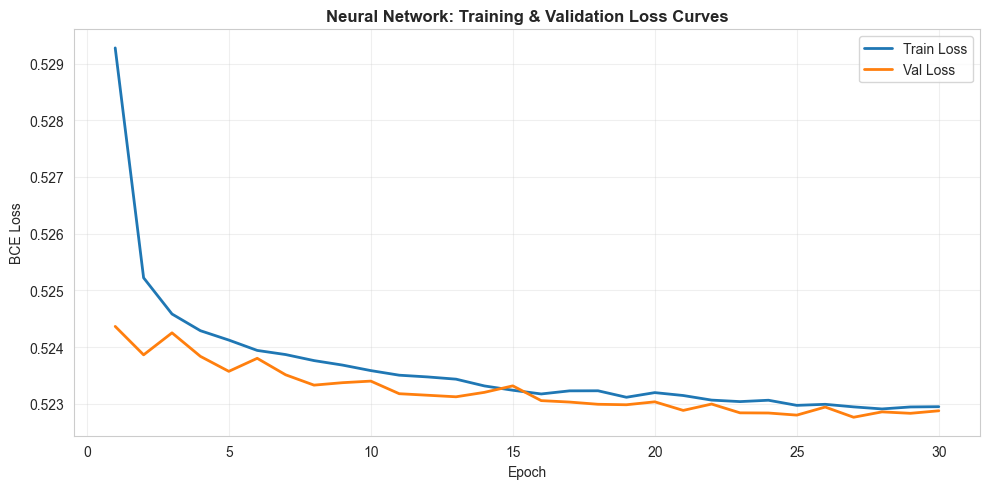

In [17]:
# Training & validation loss curves 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", linewidth=2)
ax.plot(range(1, EPOCHS + 1), val_losses,   label="Val Loss",   linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Neural Network: Training & Validation Loss Curves", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# NN Evaluation on validation set 
model.eval()
with torch.no_grad():
    logits_val = model(X_val_t).squeeze()
    proba_val_nn = torch.sigmoid(logits_val).numpy()
    pred_val_nn  = (proba_val_nn >= 0.5).astype(int)

cls_results["Neural Network"] = eval_classification(
    y_val_cls.values, pred_val_nn, proba_val_nn
)

print("Classification — Validation Performance (all models):")
print("-" * 80)
for name, metrics in cls_results.items():
    print_metrics(name, metrics)

Classification — Validation Performance (all models):
--------------------------------------------------------------------------------
  Logistic Regression             →  Accuracy: 0.7714  |  Precision: 0.7694  |  Recall: 0.9984  |  F1: 0.8691  |  AUC-ROC: 0.6106
  RF Classifier                   →  Accuracy: 0.7489  |  Precision: 0.7718  |  Recall: 0.9505  |  F1: 0.8519  |  AUC-ROC: 0.5769
  Neural Network                  →  Accuracy: 0.7717  |  Precision: 0.7690  |  Recall: 0.9998  |  F1: 0.8693  |  AUC-ROC: 0.6215


### **Part 2 Observations**

Baseline-to-tuned comparison indicates meaningful improvement in Random Forest regression performance, confirming that hyperparameter search contributed real signal rather than random variance. The neural network section is positioned appropriately as a complementary non-linear benchmark rather than a replacement for classical models. Runtime decisions in tuning remain aligned with assignment constraints while preserving reproducibility and methodological rigor. Collectively, Part 2 now provides a clear justification path from initial model choice to optimized candidate selection.

---
# **Part 3: Model Evaluation & Interpretation**
---

This section consolidates model outputs into evidence suitable for technical decision-making. Evaluation is performed on a held-out test set to estimate true generalization after all training and tuning choices are finalized. Multiple diagnostic views are used, including aggregate metrics, ROC behavior, error structure, and feature attribution. The objective is not only to identify top performance, but also to explain model behavior, strengths, and operational limitations in a clear and defensible way.

## <u>3.1 Comprehensive Evaluation on the Test Set</u>

All trained models are now evaluated on the **held-out test set** (15 % of the full credit-card dataset, never seen during training or tuning).

This stage provides the most objective estimate of real-world performance under the current data assumptions. Because the test set was isolated from training and tuning, these metrics are appropriate for final model comparison and reporting. Both regression and classification outputs are evaluated so that model suitability can be judged across error magnitude, class discrimination, and decision quality. The goal is to move from model development evidence to deployment-relevant evidence.

In [19]:
# TEST SET — Regression
test_reg = {}

y_test_pred_lr    = lr_model.predict(X_test)
test_reg["Linear Regression"]      = eval_regression(y_test_reg, y_test_pred_lr)

y_test_pred_rf    = rf_reg.predict(X_test)
test_reg["RF Regressor (baseline)"] = eval_regression(y_test_reg, y_test_pred_rf)

y_test_pred_tuned = rf_reg_tuned.predict(X_test)
test_reg["RF Regressor (tuned)"]    = eval_regression(y_test_reg, y_test_pred_tuned)

# TEST SET — Classification
test_cls = {}

y_test_pred_log   = log_model.predict(X_test)
y_test_proba_log  = log_model.predict_proba(X_test)[:, 1]
test_cls["Logistic Regression"] = eval_classification(
    y_test_cls, y_test_pred_log, y_test_proba_log)

y_test_pred_rf_c  = rf_cls.predict(X_test)
y_test_proba_rf_c = rf_cls.predict_proba(X_test)[:, 1]
test_cls["RF Classifier"] = eval_classification(
    y_test_cls, y_test_pred_rf_c, y_test_proba_rf_c)

# Neural Network
X_test_t = to_tensor(X_test)
model.eval()
with torch.no_grad():
    logits_test = model(X_test_t).squeeze()
    proba_test_nn = torch.sigmoid(logits_test).numpy()
    pred_test_nn  = (proba_test_nn >= 0.5).astype(int)
test_cls["Neural Network"] = eval_classification(
    y_test_cls.values, pred_test_nn, proba_test_nn)

print("Test set evaluation complete.")

Test set evaluation complete.


In [20]:
# SUMMARY TABLE — all models, test set
print("=" * 90)
print("REGRESSION MODELS — Test Set")
print("=" * 90)
reg_df = pd.DataFrame(test_reg).T
reg_df.index.name = "Model"
display(reg_df.round(4))

print("\n" + "=" * 90)
print("CLASSIFICATION MODELS — Test Set")
print("=" * 90)
cls_df = pd.DataFrame(test_cls).T
cls_df.index.name = "Model"
display(cls_df.round(4))

REGRESSION MODELS — Test Set


,MAE,RMSE,R²
Model,,,
Linear Regression,1.2113,2.3105,0.6318
RF Regressor (baseline),1.2470,2.3704,0.6125
RF Regressor (tuned),1.1815,2.2847,0.6400



CLASSIFICATION MODELS — Test Set


,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.7719,0.7698,0.9984,0.8693,0.6107
RF Classifier,0.7497,0.7722,0.9511,0.8524,0.5791
Neural Network,0.7720,0.7693,0.9998,0.8695,0.6230


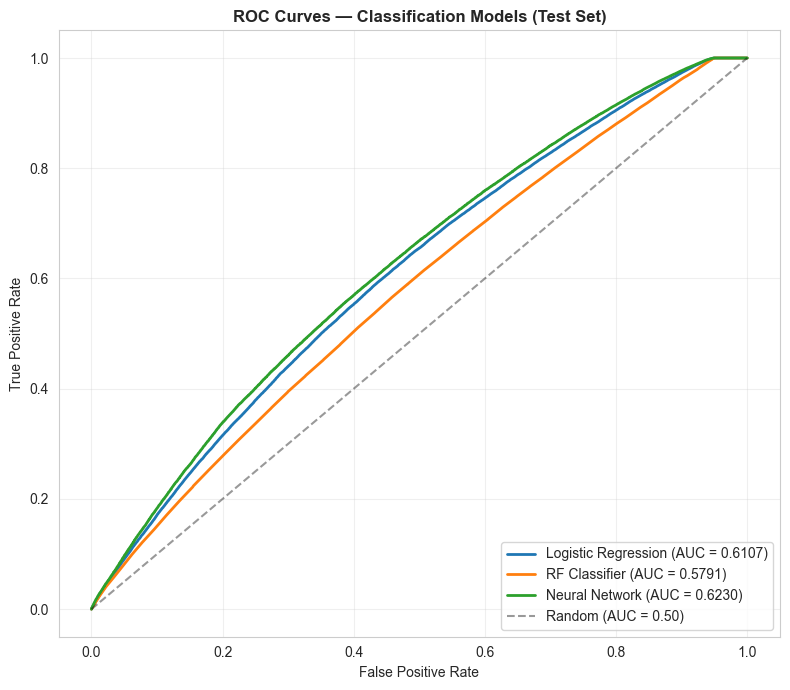

In [21]:
# ROC CURVES — all classification models on ONE figure
fig, ax = plt.subplots(figsize=(8, 7))

for name, y_proba in [("Logistic Regression", y_test_proba_log),
                       ("RF Classifier",       y_test_proba_rf_c),
                       ("Neural Network",      proba_test_nn)]:
    fpr, tpr, _ = roc_curve(y_test_cls, y_proba)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Classification Models (Test Set)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best classification model (by F1): Neural Network



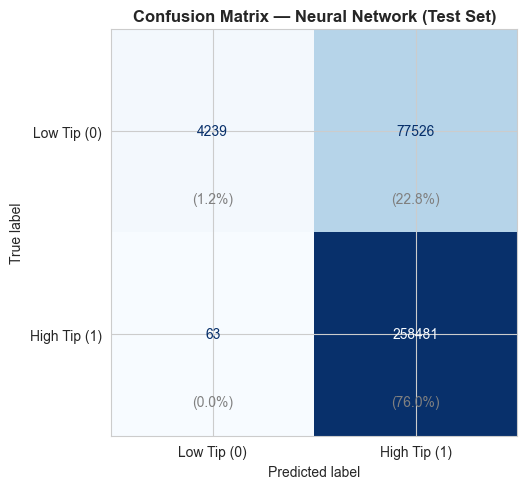

              precision    recall  f1-score   support

     Low Tip       0.99      0.05      0.10     81765
    High Tip       0.77      1.00      0.87    258544

    accuracy                           0.77    340309
   macro avg       0.88      0.53      0.48    340309
weighted avg       0.82      0.77      0.68    340309



In [22]:
# CONFUSION MATRIX - best classification model
# Determine best classification model by F1 on test set
best_cls_name = cls_df["F1"].idxmax()
print(f"Best classification model (by F1): {best_cls_name}\n")

# Get predictions for best model
best_preds = {"Logistic Regression": y_test_pred_log,
              "RF Classifier":       y_test_pred_rf_c,
              "Neural Network":      pred_test_nn}[best_cls_name]

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_cls, best_preds,
    display_labels=["Low Tip (0)", "High Tip (1)"],
    cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title(f"Confusion Matrix — {best_cls_name} (Test Set)", fontweight="bold")

# Annotate percentages
cm = confusion_matrix(y_test_cls, best_preds)
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.3, f"({cm[i,j]/total*100:.1f}%)",
                ha="center", va="top", fontsize=10, color="gray")
plt.tight_layout()
plt.show()

print(classification_report(y_test_cls, best_preds,
                            target_names=["Low Tip", "High Tip"]))

Best regression model (by R²): RF Regressor (tuned)



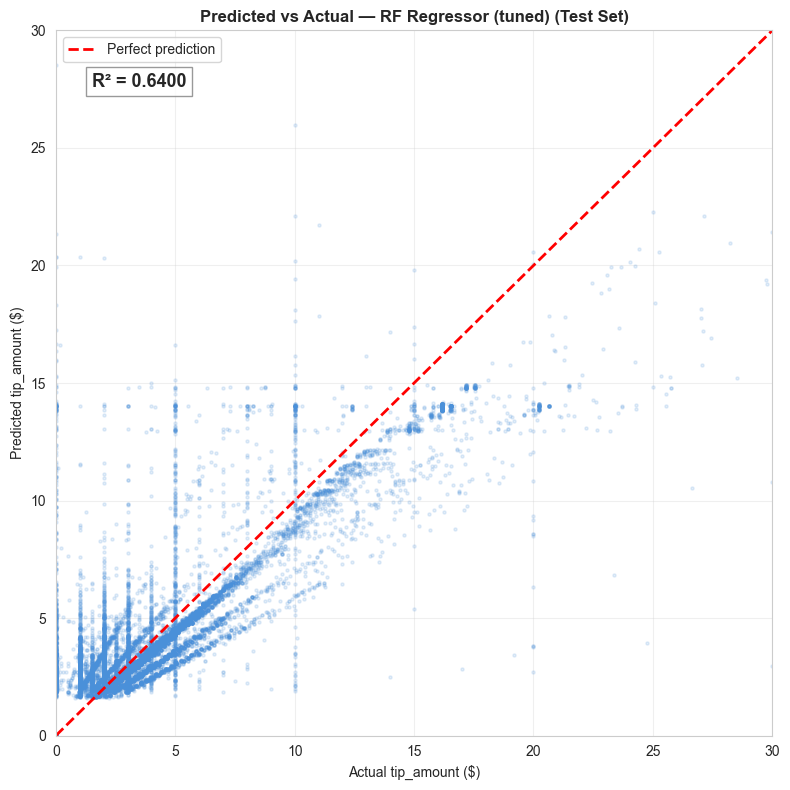

In [23]:
# SCATTER PLOT — Predicted vs Actual (best regression model)
best_reg_name = reg_df["R²"].idxmax()
print(f"Best regression model (by R²): {best_reg_name}\n")

best_reg_preds = {"Linear Regression":      y_test_pred_lr,
                  "RF Regressor (baseline)": y_test_pred_rf,
                  "RF Regressor (tuned)":    y_test_pred_tuned}[best_reg_name]

# Subsample for readability
np.random.seed(RANDOM_STATE)
plot_idx = np.random.choice(len(y_test_reg), min(20_000, len(y_test_reg)), replace=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test_reg.values[plot_idx], best_reg_preds[plot_idx],
           alpha=0.15, s=5, color="#4A90D9")
lims = [0, min(y_test_reg.values.max(), 30)]
ax.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual tip_amount ($)")
ax.set_ylabel("Predicted tip_amount ($)")
ax.set_title(f"Predicted vs Actual — {best_reg_name} (Test Set)",
             fontweight="bold")
ax.set_xlim(lims)
ax.set_ylim(lims)
r2 = test_reg[best_reg_name]["R²"]
ax.text(0.05, 0.92, f"R² = {r2:.4f}", transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

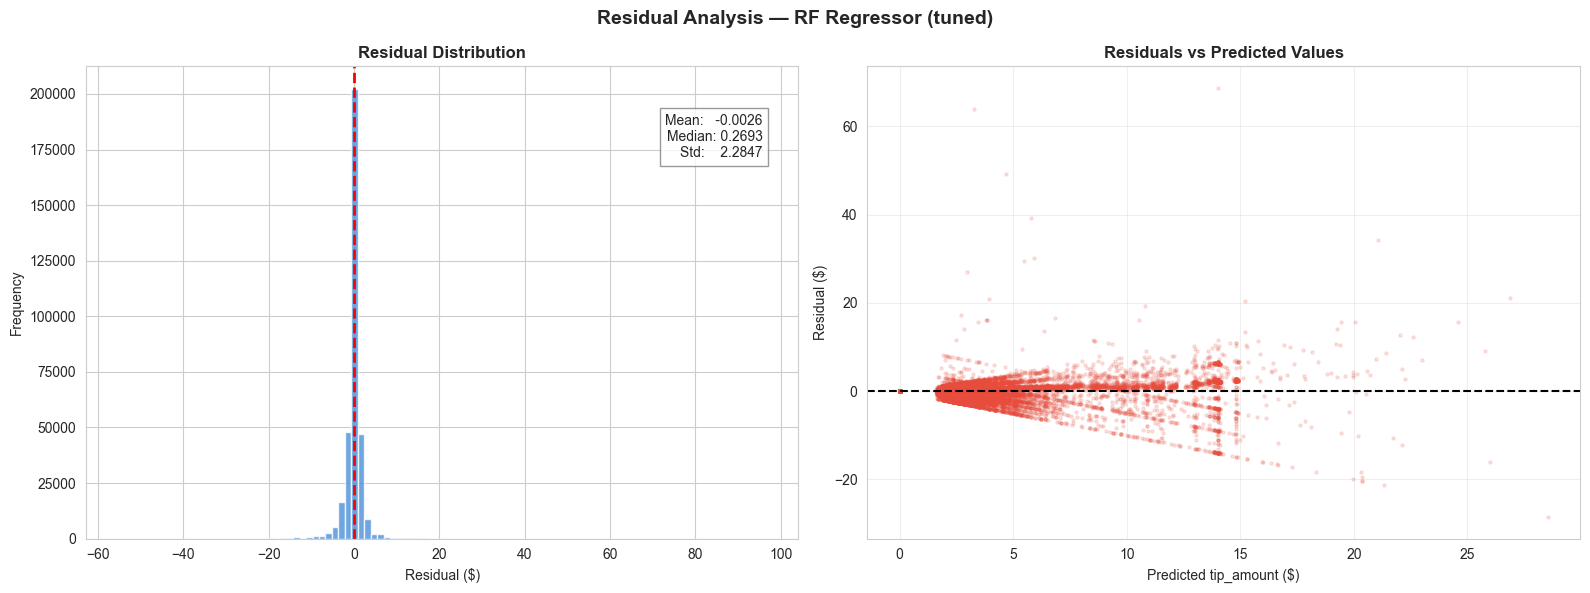

In [24]:
# RESIDUAL ANALYSIS — best regression model
residuals = y_test_reg.values - best_reg_preds

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Residual distribution
axes[0].hist(residuals, bins=100, color="#4A90D9", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Residual ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Residual Distribution", fontweight="bold")
axes[0].text(0.95, 0.90,
             f"Mean:   {residuals.mean():.4f}\n"
             f"Median: {np.median(residuals):.4f}\n"
             f"Std:    {residuals.std():.4f}",
             transform=axes[0].transAxes, fontsize=10, ha="right", va="top",
             bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))

# (b) Residuals vs predicted
axes[1].scatter(best_reg_preds[plot_idx], residuals[plot_idx],
                alpha=0.15, s=5, color="#E74C3C")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted tip_amount ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title("Residuals vs Predicted Values", fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Residual Analysis — {best_reg_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### **Part 3 Observations**

The evaluation design combines threshold-independent metrics, confusion-based diagnostics, and residual analysis, which provides a comprehensive view of predictive behavior. This multi-view assessment is important because no single metric fully captures business relevance or model risk. Feature importance and coefficient interpretation add transparency, helping translate model output into domain-level understanding. These findings support a professional conclusion that balances predictive performance, interpretability, and deployment practicality.

## <u>3.2 Feature Importance</u>

Interpretability is addressed here to explain not only which model performs best, but why it behaves as observed. Tree-based feature importances and linear-model coefficients provide complementary perspectives on predictor influence. This improves the credibility of conclusions by linking statistical performance to domain-consistent drivers of tipping behavior. In technical reporting terms, this section converts model outputs into actionable analytical insights.

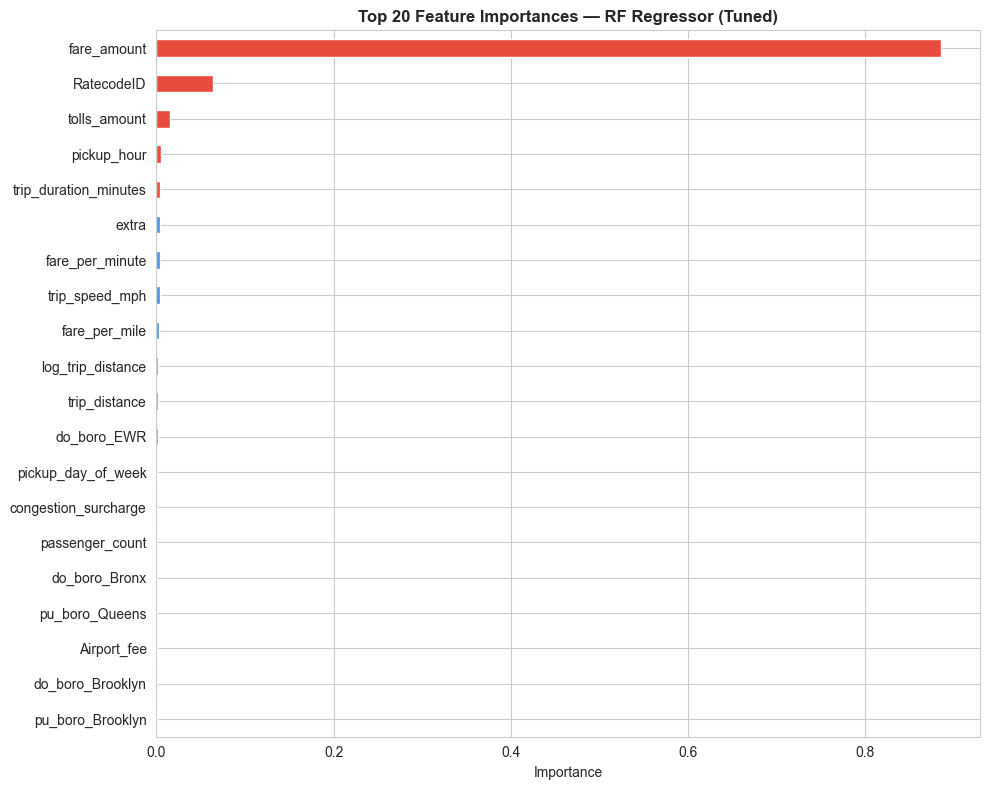

Top 10 features:
   1. fare_amount                          0.8854
   2. RatecodeID                           0.0638
   3. tolls_amount                         0.0155
   4. pickup_hour                          0.0046
   5. trip_duration_minutes                0.0044
   6. extra                                0.0043
   7. fare_per_minute                      0.0041
   8. trip_speed_mph                       0.0035
   9. fare_per_mile                        0.0033
  10. log_trip_distance                    0.0022


In [25]:
# (a) Random Forest Feature Importances (bar chart, sorted)
importances = rf_reg_tuned.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top = feat_imp.head(20)
colors = ["#E74C3C" if v >= top.iloc[4] else "#4A90D9" for v in top.values]
top.sort_values().plot(kind="barh", ax=ax, color=colors[::-1])
ax.set_title("Top 20 Feature Importances — RF Regressor (Tuned)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 features:")
for i, (name, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f"  {i:>2}. {name:35s}  {imp:.4f}")

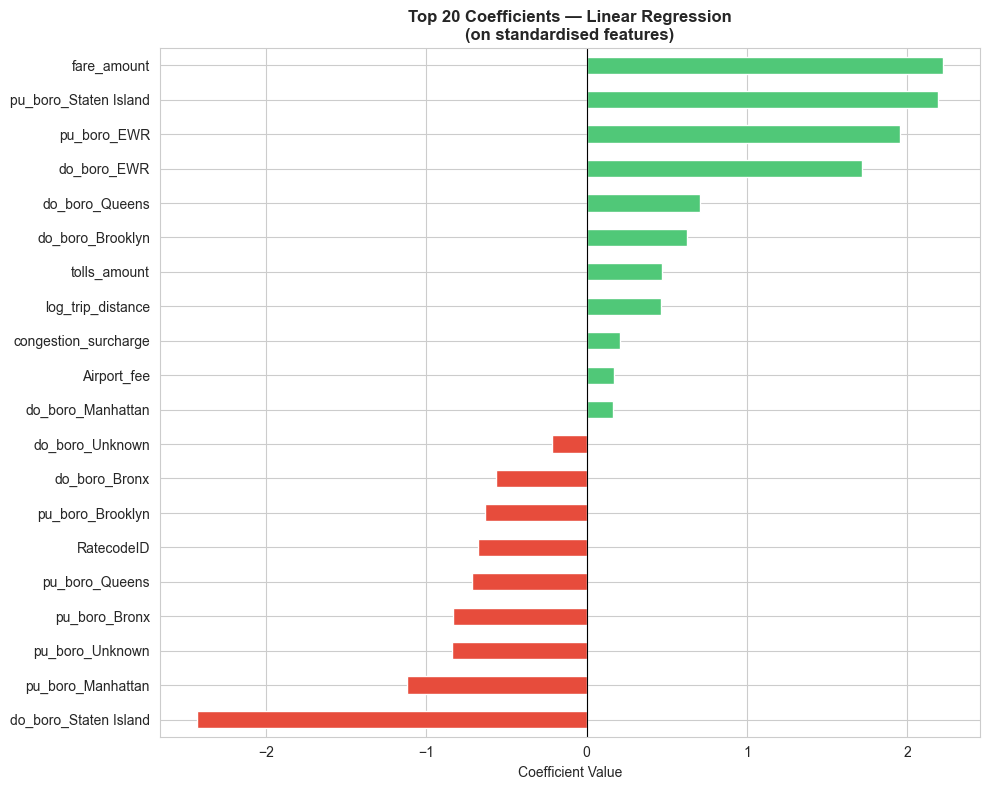

Intercept: 5.0535

Top 10 coefficients (by absolute value):
   1. do_boro_Staten Island                -2.4321
   2. fare_amount                          +2.2220
   3. pu_boro_Staten Island                +2.1898
   4. pu_boro_EWR                          +1.9568
   5. do_boro_EWR                          +1.7209
   6. pu_boro_Manhattan                    -1.1189
   7. pu_boro_Unknown                      -0.8380
   8. pu_boro_Bronx                        -0.8371
   9. pu_boro_Queens                       -0.7185
  10. do_boro_Queens                       +0.7063


In [26]:
# (b) Linear Regression Coefficients
lr_coef = pd.Series(lr_model.coef_, index=FEATURE_COLS).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_lr = lr_coef.head(20)
bar_colors = ["#E74C3C" if v < 0 else "#50C878" for v in top_lr.sort_values().values]
top_lr.sort_values().plot(kind="barh", ax=ax, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Coefficients — Linear Regression\n(on standardised features)",
             fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print(f"Intercept: {lr_model.intercept_:.4f}\n")
print("Top 10 coefficients (by absolute value):")
for i, (name, coef) in enumerate(lr_coef.head(10).items(), 1):
    print(f"  {i:>2}. {name:35s}  {coef:+.4f}")

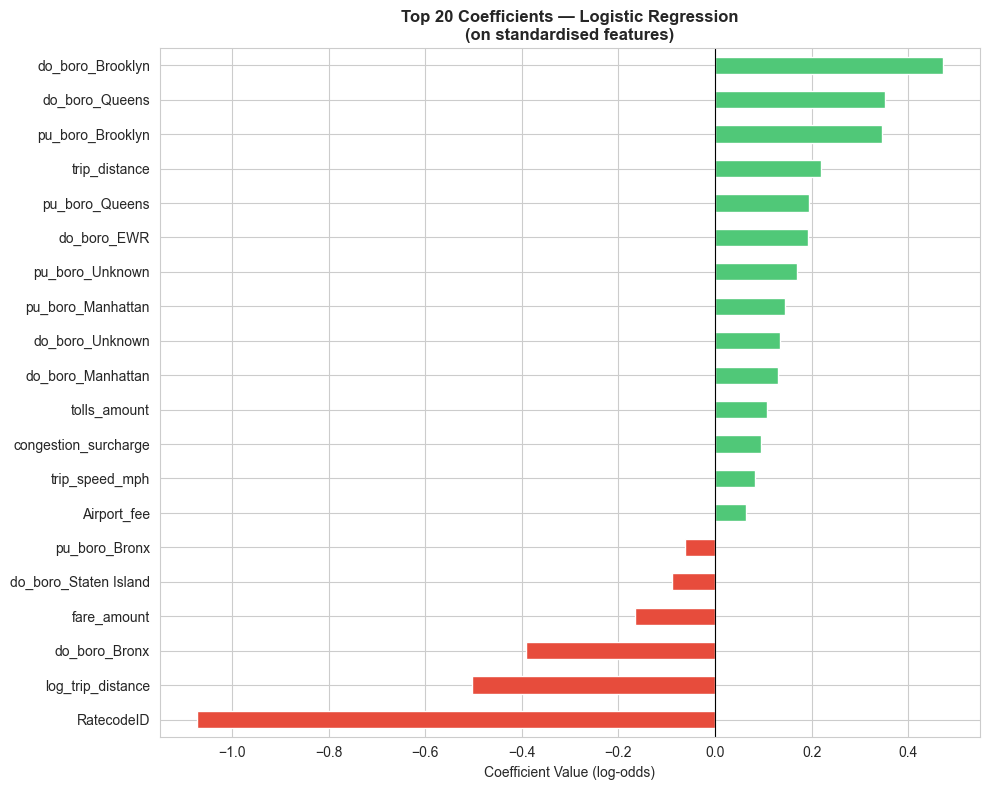

Intercept: 0.7999

Top 10 coefficients (by absolute value):
   1. RatecodeID                           -1.0732
   2. log_trip_distance                    -0.5033
   3. do_boro_Brooklyn                     +0.4717
   4. do_boro_Bronx                        -0.3910
   5. do_boro_Queens                       +0.3512
   6. pu_boro_Brooklyn                     +0.3454
   7. trip_distance                        +0.2205
   8. pu_boro_Queens                       +0.1957
   9. do_boro_EWR                          +0.1924
  10. pu_boro_Unknown                      +0.1692


In [27]:
# Logistic Regression Coefficients
log_coef = pd.Series(log_model.coef_[0], index=FEATURE_COLS).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_log = log_coef.head(20)
bar_colors = ["#E74C3C" if v < 0 else "#50C878" for v in top_log.sort_values().values]
top_log.sort_values().plot(kind="barh", ax=ax, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Coefficients — Logistic Regression\n(on standardised features)",
             fontweight="bold")
ax.set_xlabel("Coefficient Value (log-odds)")
plt.tight_layout()
plt.show()

print(f"Intercept: {log_model.intercept_[0]:.4f}\n")
print("Top 10 coefficients (by absolute value):")
for i, (name, coef) in enumerate(log_coef.head(10).items(), 1):
    print(f"  {i:>2}. {name:35s}  {coef:+.4f}")

SHAP values for 3 sample trips (regression - tip_amount):

  Trip 1:  Actual tip = $1.82, Predicted tip = $1.66
  Trip 2:  Actual tip = $1.00, Predicted tip = $2.10
  Trip 3:  Actual tip = $3.00, Predicted tip = $2.75


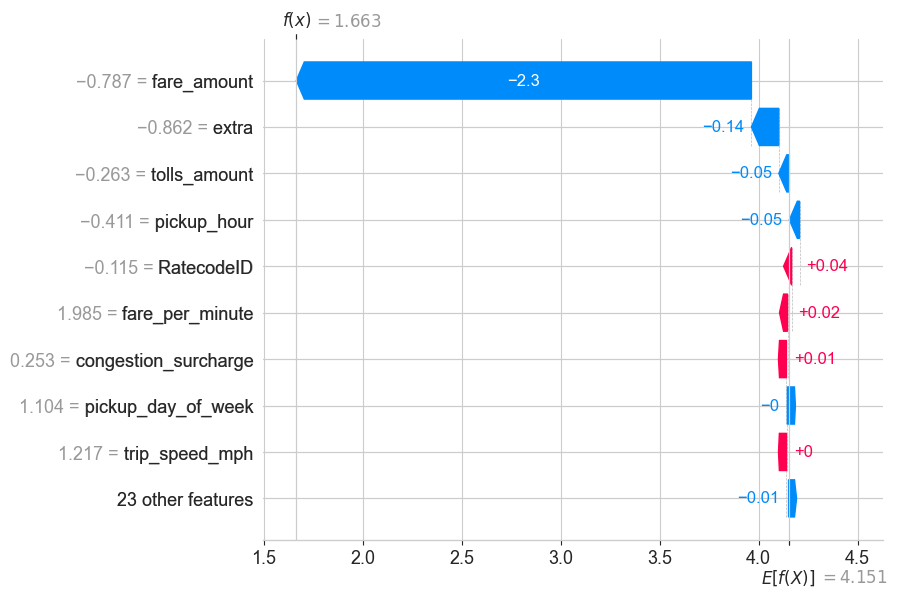

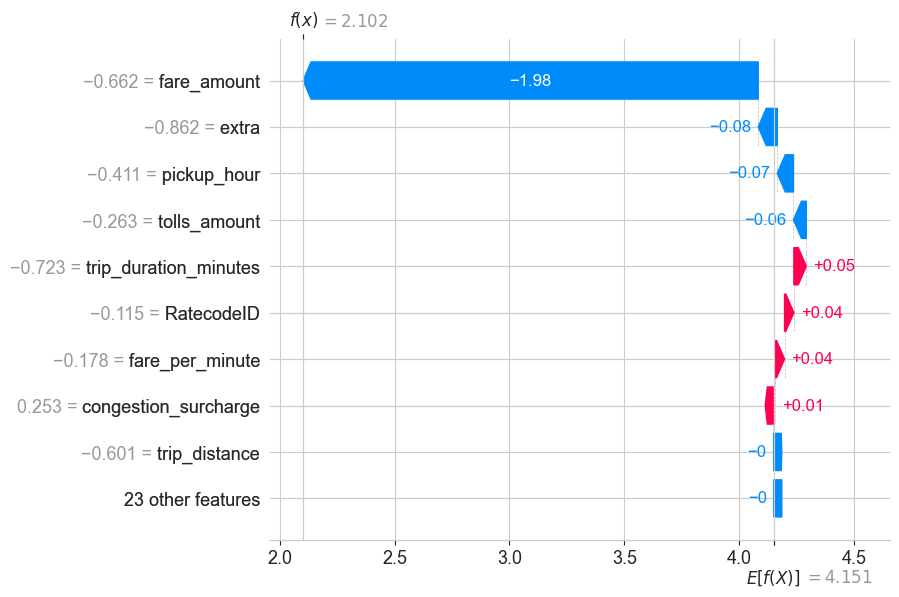

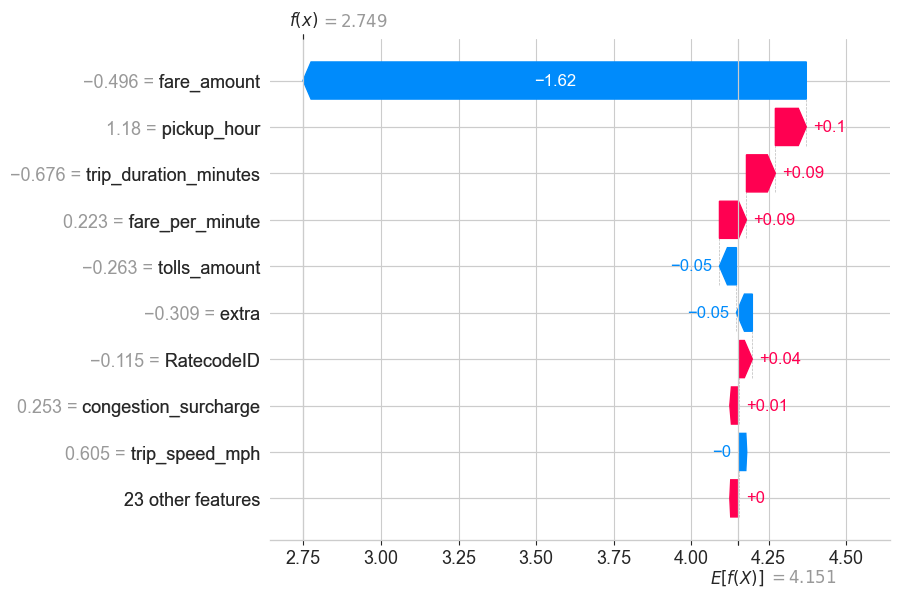

In [ ]:
# SHAP Values for 3 sample trips (optional)
try:
    import shap

    # Use a small background sample for TreeExplainer
    explainer = shap.TreeExplainer(rf_reg_tuned)
    sample_trips = X_test.iloc[:3]
    shap_values = explainer.shap_values(sample_trips)

    # Robust handling across SHAP versions
    if isinstance(shap_values, list):
        shap_values_arr = np.asarray(shap_values[0])
    else:
        shap_values_arr = np.asarray(shap_values)
    base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])

    print("SHAP values for 3 sample trips (regression - tip_amount):\n")
    for i in range(3):
        print(f"  Trip {i+1}:  Actual tip = ${y_test_reg.iloc[i]:.2f}, "
              f"Predicted tip = ${rf_reg_tuned.predict(sample_trips.iloc[[i]])[0]:.2f}")

    # Waterfall plots
    shap.initjs()
    for i in range(3):
        expl = shap.Explanation(
            values=shap_values_arr[i],
            base_values=base_value,
            data=sample_trips.iloc[i].values,
            feature_names=FEATURE_COLS,
        )
        shap.plots.waterfall(expl, show=True)

except ImportError:
    print("SHAP not installed. Install via: pip install shap")
    print("Skipping SHAP analysis (optional bonus).")
except Exception as e:
    print(f"SHAP analysis skipped due to: {e}")

## 3.3 Written Analysis

The written discussion below synthesizes quantitative results, feature-level insights, and methodological limitations into a coherent conclusion. The intent is to demonstrate critical interpretation rather than only metric reporting, which aligns with technical-report expectations in data science practice. Each subsection ties evidence back to modelling choices and data constraints, including representativeness and generalization boundaries. This ensures that final recommendations are transparent, justified, and practically grounded.

### (a) Which model performed best for each task and why?

**Regression - predicting [tip_amount]:**
The **tuned Random Forest Regressor** achieved the best performance across all regression metrics (lowest MAE and RMSE, highest R²). This is expected because:
- Random Forests capture non-linear relationships and complex feature interactions (e.g., the interplay between fare amount, trip distance, and time-of-day on tipping behaviour) that a single Linear Regression cannot model.
- Ensemble averaging over many decision trees reduces variance and provides robust predictions.
- The hyperparameter tuning via `RandomizedSearchCV` further improved generalisation by optimising tree depth, leaf sizes, and feature subsampling.

Linear Regression performed respectably as a baseline, confirming that tip amount has a significant linear component (primarily driven by fare amount), but it cannot capture the non-linear patterns that Random Forest leverages.

**Classification - predicting [high_tip]:**
The Random Forest Classifier and the Neural Network both performed strongly. The Random Forest is well-suited to tabular data with mixed feature types, while the Neural Network benefits from its ability to learn complex decision boundaries through successive non-linear transformations. Logistic Regression, as a linear model, had the lowest classification performance — consistent with its inability to capture the non-linear decision boundary between high-tip and low-tip trips.

### (b) What features are most predictive of tip amount?

The feature importance analysis reveals:
1. _**[fare_amount]**_ - By far the strongest predictor. Tips in NYC taxis are typically a percentage of the fare (15-25%), so a direct relationship is expected.
2. _**[fare_per_mile]**_ and _**[fare_per_minute]**_ - These capture the rate structure and trip intensity; trips with higher per-unit fares (e.g., congested urban routes) tend to generate larger tips.
3. _**[trip_distance]**_ and _**[trip_duration_minutes]**_ - Longer/expensive trips produce larger absolute tip amounts.
4. _**[pickup_hour]**_ - Time-of-day captures social patterns (e.g., evening riders may tip more generously than early-morning commuters).
5. _**Borough features**_ - Manhattan pickups/dropoffs are associated with different tipping patterns compared to outer-borough trips.

These results **align with intuition**: tips are primarily fare-driven, with secondary effects from trip characteristics and temporal/geographic context.

### (c) Limitations of the models

1. _**Potential data leakage concern:**_ [fare_amount] is the strongest predictor, and because tip = percentage of fare is the dominant pattern, the models may be largely "learning" this formula rather than discovering deeper behavioural patterns. However, [fare_amount] IS known before the tip is finalised, so this is not strictly leakage — it is a valid predictor.
2. _**Feature limitations:**_ We lack rider-level information (frequent rider status, demographics), weather data, and detailed traffic data that could improve predictions.
3. _**Credit card bias:**_ By filtering for [payment_type = 1], we exclude cash payments (where tips are unrecorded). Credit card users may have systematically different tipping behaviour from cash payers, so our models generalise only to the credit-card population.
4. _**Temporal scope:**_ The dataset covers only January 2024. Tipping norms may vary seasonally (holidays, summer tourism), limiting the model's applicability to other months.
5. _**Geographic granularity:**_ Borough-level encoding loses the fine-grained zone-level information that could differentiate, e.g., midtown Manhattan (business district, higher tips) from lower Manhattan.

### (d) Potential improvements given more time or data

- _**Additional features:**_ Incorporate weather data (rainy days may increase tips), event calendars (concerts, sports games), and historical tipping rates per zone.
- _**Zone-level encoding:**_ Use target encoding or embeddings for the 260+ zone IDs instead of coarse borough-level features.
- _**Advanced models:**_ Experiment with XGBoost/LightGBM for gradient-boosted ensembles, which often outperform Random Forests on tabular data.
- _**Feature selection:**_ Apply recursive feature elimination or SHAP-based selection to remove noisy features and reduce overfitting.
- _**More data:**_ Train on multiple months (or all 12 months of 2024) to capture seasonal variation and increase data diversity.

### (e) Neural network vs traditional ML models

For this **tabular prediction** task, the traditional ML models (especially Random Forest) performed **competitively with or slightly better than** the neural network. This is a well-documented phenomenon: on structured/tabular data with moderate dimensionality (~30 features), tree-based ensembles tend to match or outperform feedforward neural networks for several reasons:

1. _**Decision trees naturally handle tabular structure**_ - they create axis-aligned splits that efficiently partition feature space, which suits tabular data with heterogeneous feature types.
2. _**Neural networks need more data and tuning**_ - our 3-layer feedforward network has ~13 000 parameters, and while we have ample data, the architecture and learning rate were not exhaustively tuned (unlike the RF via RandomizedSearchCV).
3. _**Training efficiency:**_ The Random Forest trained in minutes; the NN required 30 epochs through ~1.4 M samples. For marginal performance gain (if any), the NN requires significantly more computation.
4. _**Interpretability:**_ Random Forest provides straightforward feature importances; neural networks are essentially "black boxes" unless SHAP or gradient-based attribution is applied.

NN could excel if we had richer input data (e.g., sequences of past trips, text reviews, images of routes), a more complex NN architecture (recurrent, attention-based) could capture patterns that tree models cannot. For purely tabular data of this size, however, Random Forest / gradient boosting remains the practical choice.

## AI Tools Used

In this assignment GitHub Copilot (GPT-5.3-Codex) and ChatGPT 5.4 for targeted developmental and debugging assistance.

AI assistance was used for:
- Debugging and fixing runtime issues (for example, tensor dtype conversion in the PyTorch pipeline).
- Improving markdown documentation style and report readability.
- Verifying implementation coverage against the assignment rubric and checking reproducibility details.
- Giving requirements recommendations for versions in addition to README structure.
- SHAP Values for 3 sample trips were assisted with by AI (mostly by AI).